In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
def corr2d(X, K): #@save
    h, w = K.shape
    Y = torch.zeros((X.shape[0]-h+1, X.shape[1]-w+1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y


In [3]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])

In [4]:
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [5]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

In [6]:
#Simple object edge detection using convolutional layer
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [7]:
K = torch.tensor([[1.0, -1.0]])

In [8]:
Y = corr2d(X, K)
Y
#Value of 1 detects change from white to black pixel while a value of -1 detects change from black to white pixel.

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [9]:
#Above kernel only detects vertical edges but fails to detect horizontal edges
corr2d(X.t(), K)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [10]:
#Manually deciding the value of kernel is difficult and almost impossible when we construct a model with multiple convolutional layer as it becomes
#difficult to understand what each kernel of each layer should do manually.
#To find optimal value of kernel we can use gradient descent with squared error to compare Y with output of convolutional layer


conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)
# conv2d = Conv2D(kernel_size=(1, 2))

#Here our input and output is of 4 dimensions of form (example, channel, height, width)
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))

In [11]:
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y-Y_hat) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i+1) % 2 == 0:
        print(f'epoch {i + 1}, loss {l.sum():.3f}')

epoch 2, loss 1.899
epoch 4, loss 0.319
epoch 6, loss 0.054
epoch 8, loss 0.009
epoch 10, loss 0.002


In [12]:
#Kernel learned after 10 iterations
conv2d.weight.data

tensor([[[[ 0.9936, -0.9921]]]])

In [13]:
X = torch.ones((8, 8))
for i in range(8):
    X[i ,i] = 0
X

tensor([[0., 1., 1., 1., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 1., 1.],
        [1., 1., 0., 1., 1., 1., 1., 1.],
        [1., 1., 1., 0., 1., 1., 1., 1.],
        [1., 1., 1., 1., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1., 0., 1.],
        [1., 1., 1., 1., 1., 1., 1., 0.]])

In [14]:
Y = corr2d(X, K)
Y

tensor([[-1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1., -1.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1., -1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  1., -1.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  1., -1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  1., -1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  1., -1.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1.]])

In [15]:
corr2d(X.t(), K)

tensor([[-1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1., -1.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1., -1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  1., -1.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  1., -1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  1., -1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  1., -1.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1.]])

In [16]:
corr2d(X, K.t())

tensor([[-1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., -1.,  1.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., -1.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., -1.,  1.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., -1.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., -1.,  1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  1.]])

In [17]:
def comp_conv2d(conv2d, X):
    X = X.reshape((1 , 1) + X.shape)
    Y = conv2d(X)
    return Y.reshape(Y.shape[2:])

In [18]:
#Here we use padding to preserve dimensionality between input and output.
conv2d = nn.LazyConv2d(1, kernel_size=(3, 3), padding=(1, 1))
X = torch.randn((8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

In [19]:
#Striding
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

In [20]:
conv2d = nn.LazyConv2d(1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])

In [21]:
def mirror_padding(X, padding_size):
    # Check if padding_size is a tuple or single value
    # if isinstance(padding_size, int):
    #     padding_size = (padding_size, padding_size)
    # elif len(padding_size) != 2:
    #     raise ValueError("padding_size should be a single value or a tuple of two values")
    X = X.reshape((1, 1) + X.shape)
    # Get dimensions of input tensor
    batch_size, num_channels, height, width = X.size()

    # Pad along height and width dimensions
    padded_tensor = torch.nn.functional.pad(X,
                                            (padding_size[1], padding_size[1], padding_size[0], padding_size[0]),
                                            mode='reflect')

    return padded_tensor

X = torch.range(1,64).reshape(8,8)
padded_tensor = mirror_padding(X, (1,1))
print("Original tensor:")
print(X)
print("Padded tensor:")
print(padded_tensor)

Original tensor:
tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12., 13., 14., 15., 16.],
        [17., 18., 19., 20., 21., 22., 23., 24.],
        [25., 26., 27., 28., 29., 30., 31., 32.],
        [33., 34., 35., 36., 37., 38., 39., 40.],
        [41., 42., 43., 44., 45., 46., 47., 48.],
        [49., 50., 51., 52., 53., 54., 55., 56.],
        [57., 58., 59., 60., 61., 62., 63., 64.]])
Padded tensor:
tensor([[[[10.,  9., 10., 11., 12., 13., 14., 15., 16., 15.],
          [ 2.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  7.],
          [10.,  9., 10., 11., 12., 13., 14., 15., 16., 15.],
          [18., 17., 18., 19., 20., 21., 22., 23., 24., 23.],
          [26., 25., 26., 27., 28., 29., 30., 31., 32., 31.],
          [34., 33., 34., 35., 36., 37., 38., 39., 40., 39.],
          [42., 41., 42., 43., 44., 45., 46., 47., 48., 47.],
          [50., 49., 50., 51., 52., 53., 54., 55., 56., 55.],
          [58., 57., 58., 59., 60., 61., 62., 63., 64., 63.],
         

C:\Users\Asus\AppData\Local\Temp\ipykernel_10660\2973693419.py:18: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  X = torch.range(1,64).reshape(8,8)


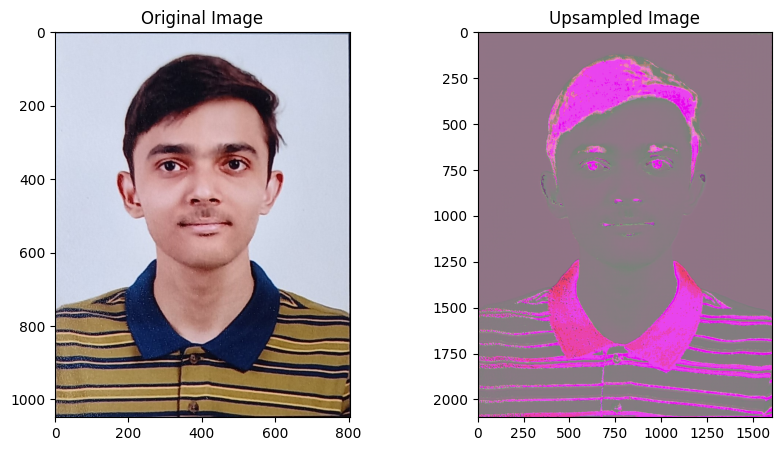

In [22]:
#Implementation of fractional striding aka transposed convolution
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
 
# Load an image
image = Image.open('myphoto.jpg')
transform = transforms.ToTensor()
image_tensor = transform(image).unsqueeze(0)
 
# Define a transposed convolutional layer for upsampling
upsample_conv = nn.ConvTranspose2d(3, 3, kernel_size=4, stride=2, padding=1)
upsampled_image_tensor = upsample_conv(image_tensor)
 
# Convert the tensor back to an image
upsampled_image = transforms.ToPILImage()(upsampled_image_tensor.squeeze(0))
 
# Display the original and upsampled images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[1].imshow(upsampled_image)
axes[1].set_title('Upsampled Image')
plt.show()

Practical relevance: Use fractionally-strided convolution when you want a learnable upsampling layer that can adapt to data-specific patterns. However, be mindful that it may need additional techniques (e.g., initialization, kernel choices) to avoid visual artifacts in generated images.

## Sample output of fractional stridding

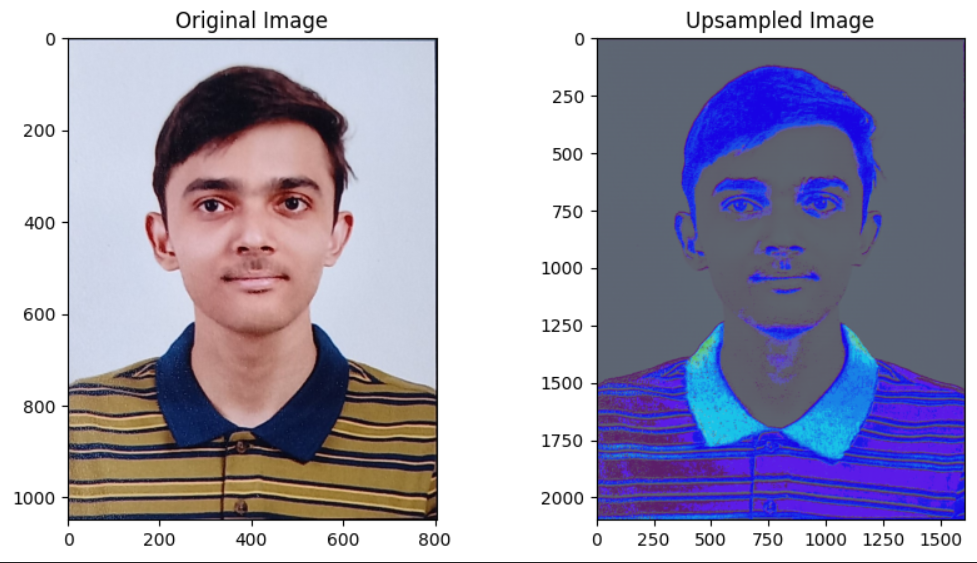

In [23]:
#Cross correlation with multiple input channels
def corr2d_multi_in(X, K):
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

In [24]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])


In [25]:
corr2d_multi_in(X, K)


tensor([[ 56.,  72.],
        [104., 120.]])

In [26]:
#Cross correlation with multiple input channels and multiple output channels
def corr2d_multi_in_out(X, K):
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [27]:
K = torch.stack((K, K + 1, K + 2), 0)
K.shape

torch.Size([3, 2, 2, 2])

In [28]:
corr2d_multi_in_out(X, K)


tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

In [29]:
# Performing covolution with kernel of size ci x 1 x 1, where ci is number of channels in input. The cross correlation operation is performed across
# channel axis.
# Let Y(i,j,ck) be the output for kth channel at (i,j) location.
# Let X(i,j,ck) be the input data at kth channel at (i, j) location.
# Then Y(i,j,ck) is linear combination of X(i,j,ck) for all k. 

#This function i equivalent to corr2d_multi_in_out.
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape(c_i, h*w)
    K = K.reshape(c_o, c_i)

    Y = torch.matmul(K, X)

    return Y.reshape(c_o, h, w)

In [30]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))
Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6


In [32]:
#Code to express convolution operation as matrix multiplication even when covolution window is not 1x1.

#The idea is to stack the input data and the kernel into a single matrix. The output is then a linear combination of the elements in the matrix.
#The linear combination is done using matrix multiplication.

import torch.nn.functional as F

def conv2d_im2col(x, weight, bias=None, stride=1, padding=0):
    """
    Performs 2D convolution using the im2col (unfold) + matrix multiplication approach.
    
    Args:
        x: Input tensor of shape (batch_size, in_channels, h, w)
        weight: Kernel tensor of shape (out_channels, in_channels, k_h, k_w)
        bias: Optional bias tensor of shape (out_channels,)
        stride: Stride of the convolution
        padding: Zero-padding added to both sides of the input
        
    Returns:
        Output tensor of shape (batch_size, out_channels, h_out, w_out)
    """
    batch_size, in_channels, h, w = x.shape
    out_channels, _, k_h, k_w = weight.shape
    
    # ---------------------------------------------------------------------
    # Step 1: Reshape the weights into a 2D matrix
    # Original shape: (out_channels, in_channels, k_h, k_w)
    # New shape: (out_channels, in_channels * k_h * k_w)
    # ---------------------------------------------------------------------
    weight_mat = weight.view(out_channels, -1)
    
    # ---------------------------------------------------------------------
    # Step 2: Extract sliding local blocks (im2col)
    # PyTorch's 'unfold' extracts the patches and flattens them.
    # Output shape: (batch_size, in_channels * k_h * k_w, num_patches)
    # where num_patches = h_out * w_out
    # ---------------------------------------------------------------------
    x_unfolded = F.unfold(x, kernel_size=(k_h, k_w), padding=padding, stride=stride)
    
    # ---------------------------------------------------------------------
    # Step 3: Perform the Matrix Multiplication (GEMM)
    # weight_mat is: (out_channels, K)
    # x_unfolded is: (batch_size, K, num_patches)
    # We unsqueeze weight_mat to (1, out_channels, K) for batched matmul.
    # Result shape: (batch_size, out_channels, num_patches)
    # ---------------------------------------------------------------------
    out_unfolded = weight_mat.unsqueeze(0) @ x_unfolded
    
    # Add bias if provided
    if bias is not None:
        out_unfolded = out_unfolded + bias.view(1, -1, 1)
        
    # ---------------------------------------------------------------------
    # Step 4: Reshape the result back to spatial dimensions
    # ---------------------------------------------------------------------
    # Calculate spatial output dimensions
    h_out = (h + 2 * padding - k_h) // stride + 1
    w_out = (w + 2 * padding - k_w) // stride + 1
    
    # Reshape from (batch_size, out_channels, num_patches) 
    # to (batch_size, out_channels, h_out, w_out)
    out = out_unfolded.view(batch_size, out_channels, h_out, w_out)
    
    return out

# ==========================================
# Verification & Testing
# ==========================================
if __name__ == "__main__":
    # Define arbitrary shapes
    batch_size = 2
    in_channels = 3
    out_channels = 16
    h, w = 32, 32
    k_h, k_w = 3, 3
    padding = 1
    stride = 2
    
    # Create random tensors
    torch.manual_seed(42) # For reproducibility
    x = torch.randn(batch_size, in_channels, h, w)
    weight = torch.randn(out_channels, in_channels, k_h, k_w)
    bias = torch.randn(out_channels)
    
    # 1. Run our im2col matrix multiplication implementation
    custom_output = conv2d_im2col(x, weight, bias, stride=stride, padding=padding)
    
    # 2. Run PyTorch's native C++ optimized convolution
    native_output = F.conv2d(x, weight, bias, stride=stride, padding=padding)
    
    # 3. Compare the results
    # We use allclose to account for tiny floating-point arithmetic differences
    is_identical = torch.allclose(custom_output, native_output, atol=1e-5)
    
    print(f"Custom im2col Output Shape: {custom_output.shape}")
    print(f"Native PyTorch Output Shape: {native_output.shape}")
    print(f"Are the outputs mathematically identical? {'Yes! ✅' if is_identical else 'No ❌'}")

Custom im2col Output Shape: torch.Size([2, 16, 16, 16])
Native PyTorch Output Shape: torch.Size([2, 16, 16, 16])
Are the outputs mathematically identical? Yes! ✅
